In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import os
import numpy as np
import torch
import torch.nn as nn
import gc
import json
import copy
from tqdm import tqdm
from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedRNN, SpatiallyEmbeddedAreaConfig
from bioplnn.utils import (
    initialize_dataloader,
    initialize_scheduler,
    manual_seed,
)
from bioplnn.base_model_configs import BASE_MODEL_CONFIGS
from scipy.stats import t

import pickle
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.dpi'] = 100

checkpoint_path = "./train/checkpoints/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import itertools

from scipy.optimize import curve_fit
import matplotlib as mpl

In [24]:
# Start from preset and ensure required input channels are set
base_cfg = copy.deepcopy(BASE_MODEL_CONFIGS["td+h-bioplnn"])
rnn_kwargs = copy.deepcopy(base_cfg["rnn_kwargs"])
area_cfgs = rnn_kwargs["area_kwargs"]
if area_cfgs[0].get("in_channels") is None:
    area_cfgs[0]["in_channels"] = 3
base_cfg["rnn_kwargs"] = rnn_kwargs

model1 = SpatiallyEmbeddedClassifier(**base_cfg)

# Save weights and config
state_path = "model.pt"
cfg_path = "config.pkl"
torch.save(model1.state_dict(), state_path)
with open(cfg_path, "wb") as f:
    pickle.dump(model1.get_config(), f)

# Reload config and rebuild model
with open(cfg_path, "rb") as f:
    loaded_cfg = pickle.load(f)

model = SpatiallyEmbeddedRNN(**loaded_cfg["rnn_kwargs"])
classifier = SpatiallyEmbeddedClassifier(**loaded_cfg)

# loaded_rnn_kwargs = loaded_cfg["rnn_kwargs"]
# loaded_area_cfgs = [
#     SpatiallyEmbeddedAreaConfig(**area_cfg)
#     for area_cfg in loaded_rnn_kwargs.pop("area_configs")
# ]
# loaded_rnn_kwargs["area_configs"] = loaded_area_cfgs

# model2 = SpatiallyEmbeddedClassifier(
#     rnn_kwargs=loaded_rnn_kwargs,
#     num_classes=loaded_cfg["num_classes"],
#     pool_size_classifier=tuple(loaded_cfg["pool_size_classifier"]),
#     pool_mode_classifier=loaded_cfg["pool_mode_classifier"],
#     fc_dim=loaded_cfg["fc_dim"],
#     dropout=loaded_cfg["dropout"],
#     output_area_index=loaded_cfg["output_area_index"],
# )
# model2.load_state_dict(torch.load(state_path, map_location="cpu"))

# # Weights should match exactly after roundtrip
# for name, param in model1.state_dict().items():
#     torch.testing.assert_close(param, model2.state_dict()[name])

None
here
(11, 11)
4
3
1
here
1
4
3
None
here
True
4
3
None
here
(7, 7)
4
3
1
here
1
4
3
None
here
True
4
3
None
here
(1, 1)
2
2
1
here
1
2
2
None
here
True
2
2
None
None
here
(11, 11)
4
3
1
here
1
4
3
None
here
True
4
3
None
here
(7, 7)
4
3
1
here
1
4
3
None
here
True
4
3
None
here
(1, 1)
2
2
1
here
1
2
2
None
here
True
2
2
None
None
here
(11, 11)
4
3
1
here
1
4
3
None
here
True
4
3
None
here
(7, 7)
4
3
1
here
1
4
3
None
here
True
4
3
None
here
(1, 1)
2
2
1
here
1
2
2
None
here
True
2
2
None


In [25]:
loaded_cfg

{'rnn_kwargs': {'num_areas': 3,
  'area_kwargs': [{'in_size': [256, 256],
    'in_channels': 3,
    'out_channels': 32,
    'feedback_channels': 32,
    'in_class': 'hybrid',
    'feedback_class': 'hybrid',
    'num_neuron_types': 2,
    'num_neuron_subtypes': array([20,  8]),
    'neuron_type_class': array(['excitatory', 'inhibitory'], dtype='<U10'),
    'neuron_type_density': 'same',
    'neuron_type_nonlinearity': 'ReLU',
    'tau_mode': 'subtype',
    'tau_init_fn': 'ones',
    'inter_neuron_type_connectivity': array([[1, 1, 0],
           [1, 0, 0],
           [1, 1, 1],
           [1, 1, 0]]),
    'inter_neuron_type_spatial_extents': (11, 11),
    'inter_neuron_type_num_subtype_groups': 1,
    'inter_neuron_type_nonlinearity': array([[None, None, None],
           [None, None, None],
           [None, None, None],
           [None, None, None]], dtype=object),
    'inter_neuron_type_bias': True,
    'out_nonlinearity': 'Identity',
    'default_neuron_state_init_fn': 'zeros',
    

In [16]:
loaded_cfg

{'rnn_kwargs': {'num_areas': 3,
  'area_time_delay': False,
  'pool_mode': 'max',
  'batch_first': True,
  'inter_area_feedback_connectivity': array([[False, False, False],
         [ True, False, False],
         [False,  True, False]]),
  'inter_area_feedback_nonlinearity': array([[None, None, None],
         [None, None, None],
         [None, None, None]], dtype=object),
  'inter_area_feedback_spatial_extents': array([[(3, 3), (3, 3), (3, 3)],
         [(3, 3), (3, 3), (3, 3)],
         [(3, 3), (3, 3), (3, 3)]], dtype=object),
  'area_configs': [SpatiallyEmbeddedAreaConfig(in_size=[256, 256], in_channels=3, out_channels=32, feedback_channels=32, in_class='hybrid', feedback_class='hybrid', num_neuron_types=2, num_neuron_subtypes=array([20,  8]), neuron_type_class=array(['excitatory', 'inhibitory'], dtype='<U10'), neuron_type_density='same', neuron_type_nonlinearity='ReLU', tau_mode='subtype', tau_init_fn='ones', inter_neuron_type_connectivity=array([[1, 1, 0],
          [1, 0, 0],


In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.gap   = nn.AdaptiveAvgPool2d(1)     # <- NEW
        self.fc1   = nn.Linear(128, 512)          # <- 64 channels only
        self.fc2   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)                          # [B, 64, 1, 1]
        x = torch.flatten(x, 1)                  # [B, 64]
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint_path, checkpoint):
    """Load model configuration and instantiate models."""

    full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_cfg = full_cfg["model_config"]
    if "num_steps" in full_cfg:
        num_steps = full_cfg["num_steps"]
    else:
        num_steps = 20

    if full_cfg["model_type"] == "cnn":
        model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
    else:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)


        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [17]:
# wandb_name = "fancy-silence-24"
# checkpoint = 370

wandb_name, checkpoint = "rosy-morning-40", 390 # new jawn

# wandb_name, checkpoint = "easy-universe-51", 449 #loss all timesteps

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint_path, checkpoint)

model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

wandb_name = "glowing-deluge-31" #CNN
checkpoint = 330

# ——— Load model config & instantiate ———
cnn_model, cnn_classifier, num_steps, cnn_cfg, cnn_state_dict = load_model_and_config(wandb_name, checkpoint_path, checkpoint)

cnn_model.eval()
cnn_model.to(device)

cnn_classifier.eval()
cnn_classifier.to(device)

/tmp/ipykernel_4078554/2837615984.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SimpleCNN(
  (conv1): Conv2d(40, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8, bias=True)
)

# Generate accuracies

In [10]:
def generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid):
    # Make ordered list of param names and value lists
    param_names = list(param_grid.keys())
    param_value_lists = [param_grid[k] for k in param_names]

    # Preallocate output array
    shape = [len(vs) for vs in param_value_lists]
    all_accuracies = np.full(shape, np.nan, dtype=float)

    # Loop over all parameter combinations, storing results in an array
    for idx, values in enumerate(tqdm(list(itertools.product(*param_value_lists)))):
        param_combo = dict(zip(param_names, values))
        index = tuple(
            param_grid[name].index(val) for name, val in zip(param_names, values)
        )

        # Build loader kwargs from this parameterization
        loader_kwargs = {
            'seed': 10,
            'dataset': "correlated_dots",
            'n_dots': param_combo['n_dots'],
            'resolution': resolution,
            'n_frames': param_combo['n_frames'],
            'correlation': param_combo['coherence'],
            'max_speed': param_combo['max_speed'],
            'samples_per_epoch': samples_per_epoch,
            'batch_size': 32,
            'num_bars': param_combo.get('num_bars', 0),                # number of vertical black bars to overlay
            'bar_width': param_combo.get('bar_width', 8),               # width in pixels of each vertical bar
            'dot_shape': param_combo.get('dot_shape', 'point'),         # 'point', 'plus', or 'circle'
            'dot_radius': param_combo.get('dot_radius', 1),              # arm length for 'plus'; ring radius for 'circle'
            'jitter_speed': param_combo.get('jitter_speed', 0.0),          # oscillatory jitter amplitude (float or (low, high))
            'evidence_pulses': param_combo.get('evidence_pulses', None),      # list of (start_t, duration, direction) tuples
        }

        data_loader, test_loader = initialize_dataloader(**loader_kwargs)

        classifier.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, labels in data_loader:
                x = x.to(device)
                if cfg["model_type"] == "cnn":
                    x = x[:, :, 0, :, :]
                    if x.shape[1] < 40:
                        # fill with zeros
                        x = torch.cat([x, torch.zeros(x.shape[0], 40 - x.shape[1], x.shape[2], x.shape[3]).to(device)], dim=1)
                    logits = classifier(x).detach().cpu()
                else:
                    logits = classifier(x, num_steps=num_steps).detach().cpu()

                if labels.ndim == 2 and labels.size(1) == 1:
                    labels = labels.squeeze(1)
                elif labels.ndim != 1:
                    raise ValueError(f"Expected labels shape [N] or [N,1], got {tuple(labels.shape)}")

                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = correct / total if total > 0 else float('nan')
        all_accuracies[index] = acc

        torch.cuda.empty_cache()
        gc.collect()

    return all_accuracies

In [ ]:
resolution = (128, 128)
samples_per_epoch = 128

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5,],
    'n_frames': [2, 5, 10, 15, 20, 25, 30, 35, 40],
    'max_speed': [1],
    'n_dots': [10, 20, 30, 50, 100, 200, 300],       # Example for easy expansion
}

all_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)

## Plot accuracy over time with varying stimulus strengths and coherences -- increased stimlulus strength results in faster and more accurate decision making
- matches psychophysiscs. see if interesting

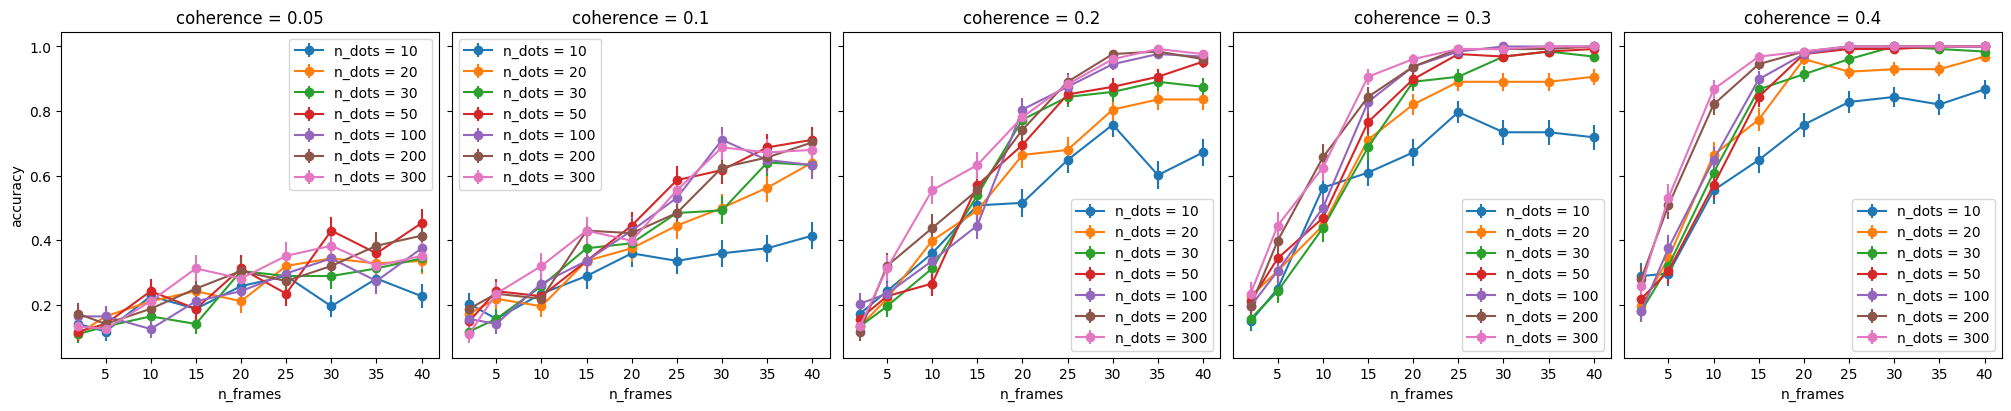

In [57]:
n_coherences = len(param_grid["coherence"])
n_n_dots = len(param_grid["n_dots"])

fig, axes = plt.subplots(1, n_coherences, figsize=(4 * n_coherences, 4), sharey=True, constrained_layout=True)

if n_coherences == 1:
    axes = [axes]  # ensure iterable

for i, coherence_idx in enumerate(range(n_coherences)):
    ax = axes[i]
    for n_dots_idx in range(n_n_dots):
        means = all_accuracies[coherence_idx, :, 0, n_dots_idx]
        confidence_interval = 1.96 * np.sqrt(means * (1 - means) / 512)
        ax.errorbar(param_grid["n_frames"], means, yerr=confidence_interval, marker="o", label=f"n_dots = {param_grid['n_dots'][n_dots_idx]}")
    ax.set_title(f"coherence = {param_grid['coherence'][coherence_idx]}")
    ax.set_xlabel("n_frames")
    if i == 0:
        ax.set_ylabel("accuracy")
    ax.legend()

plt.show()

  0%|          | 0/456 [00:00<?, ?it/s]

100%|██████████| 456/456 [06:44<00:00,  1.13it/s]


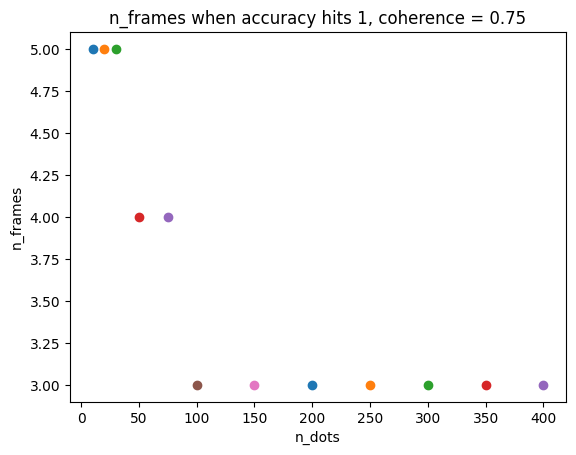

In [68]:
# another way to plot this : plot when accuracy hits 1
resolution = (128, 128)
samples_per_epoch = 128

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': [0.75],
    'n_frames': np.arange(2, 40, 1).tolist(),
    'max_speed': [1],
    'n_dots': [10, 20, 30, 50, 75, 100, 150, 200, 250, 300, 350, 400],       # Example for easy expansion
}

all_highcoherence_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)

# plot when accuracy hits 1
for i in range(len(param_grid["n_dots"])):
    acc = all_highcoherence_accuracies[-1, :, 0, i]
    # Find where accuracy hits 1 (or above)
    hit_indices = np.where(acc >= 1)[0]
    if len(hit_indices) > 0:
        first_hit_idx = hit_indices[0]
        plt.scatter(param_grid['n_dots'][i], param_grid["n_frames"][first_hit_idx])
plt.title(f"n_frames when accuracy hits 1, coherence = {param_grid['coherence'][0]}")
plt.xlabel("n_dots")
plt.ylabel("n_frames")
plt.show()


# OOD comparison

In [69]:
resolution = (128, 128)
samples_per_epoch = 128

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': [0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.3, 0.4, 0.5],
    'n_frames': [5, 10, 20, 30, 40],
    'max_speed': [1, 2, 3],
    'n_dots': [25, 100],       # Example for easy expansion
}

all_cnn_accuracies = generate_accuracies(cnn_classifier, cnn_cfg, samples_per_epoch, resolution, param_grid)
all_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)

100%|██████████| 270/270 [03:59<00:00,  1.13it/s]


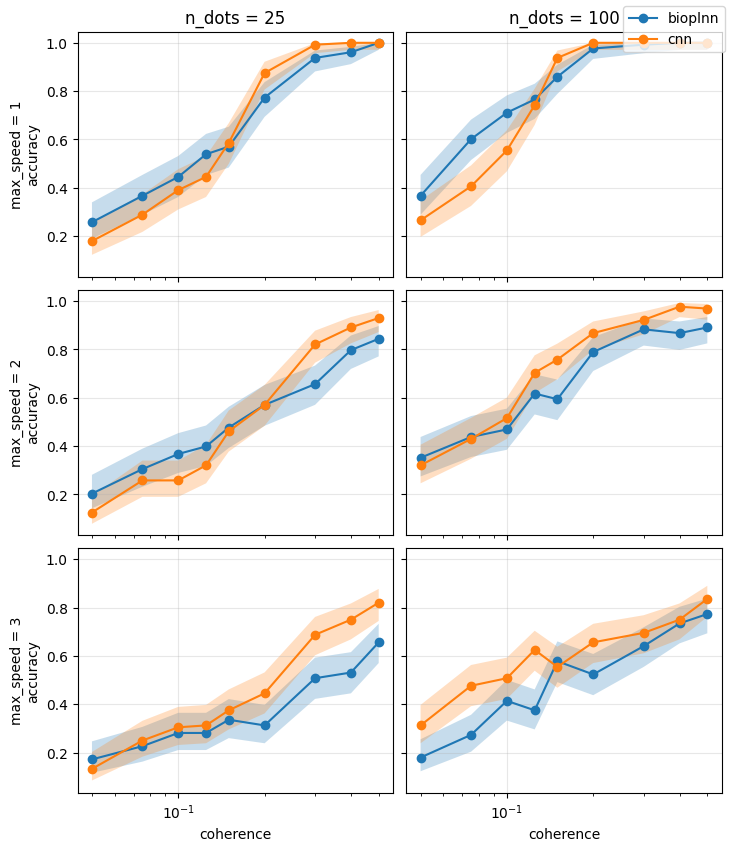

In [70]:
def wilson_ci(p, n, z=1.96):
    """
    p: array of accuracies in [0,1]
    n: number of Bernoulli trials
    Returns: lo, hi arrays
    """
    p = np.asarray(p)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return center - half, center + half

n_frames_idx = -1
num_trials = samples_per_epoch

coh = np.asarray(param_grid["coherence"])
max_speeds = param_grid["max_speed"]
n_dots_list = param_grid["n_dots"]

fig, axes = plt.subplots(
    len(max_speeds),
    len(n_dots_list),
    figsize=(3.6 * len(n_dots_list), 2.8 * len(max_speeds)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = np.atleast_2d(axes)

for i_speed, speed in enumerate(max_speeds):
    for j_dots, nd in enumerate(n_dots_list):
        ax = axes[i_speed, j_dots]

        bio = all_accuracies[:, n_frames_idx, i_speed, j_dots]
        cnn = all_cnn_accuracies[:, n_frames_idx, i_speed, j_dots]

        bio_lo, bio_hi = wilson_ci(bio, num_trials)
        cnn_lo, cnn_hi = wilson_ci(cnn, num_trials)

        ax.plot(coh, bio, label="bioplnn", marker="o")
        ax.plot(coh, cnn, label="cnn", marker="o")
        ax.fill_between(coh, bio_lo, bio_hi, alpha=0.25)
        ax.fill_between(coh, cnn_lo, cnn_hi, alpha=0.25)

        if i_speed == 0:
            ax.set_title(f"n_dots = {nd}")
        if j_dots == 0:
            ax.set_ylabel(f"max_speed = {speed}\naccuracy")

        ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("coherence")

for ax in axes.flat:
    ax.set_xscale("log")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.show()


# Psychometric curve

  0%|          | 0/70 [00:00<?, ?it/s]

100%|██████████| 70/70 [04:32<00:00,  3.90s/it]


0
10
10
1
10
10
2
10
10
3
10
10
4
10
10
5
10
10
6
10
10


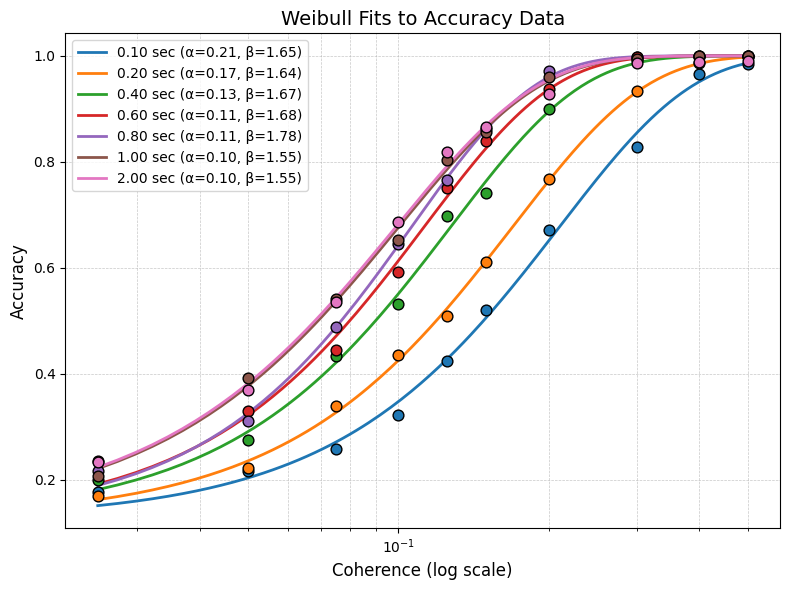

{0: (np.float64(0.21055910476823697), np.float64(1.648915072339158)),
 1: (np.float64(0.16962948855848392), np.float64(1.6418909077022477)),
 2: (np.float64(0.1275067636446069), np.float64(1.6684469050860256)),
 3: (np.float64(0.11279782297920993), np.float64(1.68463925468993)),
 4: (np.float64(0.10641850906862771), np.float64(1.7828233625996779)),
 5: (np.float64(0.10041693722670088), np.float64(1.5517424969662916)),
 6: (np.float64(0.09907014177198817), np.float64(1.5474444243782273))}

In [71]:
resolution = (128, 128)
samples_per_epoch = 512

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.3, 0.4, 0.5],
    'n_frames': [4, 8, 16, 24, 32, 40, 80],
    'max_speed': [1],
    'n_dots': [100],       # Example for easy expansion
}

all_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)

# Use a professional color palette
color_map = plt.get_cmap("tab10")  # or try "Set2", "tab20", "Dark2", etc.

# Example Weibull function
def weibull_func(x, alpha, beta):
    return 1 - (7/8) * np.exp(-((x / alpha) ** beta))

# Given arrays
n_frames_list = param_grid["n_frames"]
coherences = param_grid["coherence"]

# 1 frame is 0.025 seconds

timestamps = np.array(param_grid["n_frames"]) * 0.025

fit_params = {}

plt.figure(figsize=(8, 6))
mpl.rcParams.update({'axes.prop_cycle': mpl.cycler(color=[color_map(i) for i in range(len(param_grid["n_frames"]))])})

for n_frames_idx, n_frames in enumerate(n_frames_list):
    print(n_frames_idx)
    accuracies = all_accuracies[:, n_frames_idx, 0, 0]
    print(len(accuracies))
    print(len(coherences))

    # Fit Weibull curve
    try:
        popt, _ = curve_fit(weibull_func, coherences, accuracies, p0=[0.2, 2.0], bounds=(0, np.inf))
        alpha, beta = popt
    except RuntimeError:
        alpha, beta = np.nan, np.nan
    
    fit_params[n_frames_idx] = (alpha, beta)

    # Plot fitted curve
    x_fit = np.linspace(min(coherences), max(coherences), 200)
    y_fit = weibull_func(x_fit, alpha, beta)

    # Assign color from the palette
    color = color_map(n_frames_idx % color_map.N)

    # Plot fitted curve first (line)
    line, = plt.plot(x_fit, y_fit, "-", label=f"{timestamps[n_frames_idx]:.2f} sec (α={alpha:.2f}, β={beta:.2f})", color=color, linewidth=2)

    # Use the same color for the scatter points, with a professional marker
    plt.scatter(coherences, accuracies, color=color, marker="o", edgecolor="k", s=60, zorder=3)

plt.xscale("log")
plt.xlabel("Coherence (log scale)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(frameon=True, fontsize=10, loc="best")
plt.title("Weibull Fits to Accuracy Data", fontsize=14)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

fit_params

# Direction activation per channel

In [5]:
direction_names = {
            0: "E",
            1: "W",
            2: "N",
            3: "S",
            4: "NE",
            5: "NW",
            6: "SE",
            7: "SW"
        }
n_frames = 40
resolution = (128, 128)
correlation = 0.9
max_speed = 1
samples_per_epoch = 128*20

data_loader, test_loader = initialize_dataloader(
        seed=1, dataset="correlated_dots",
        resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=samples_per_epoch,
        batch_size=256)

In [6]:
excitatory = True

directions = {i: [] for i in range(8)}

# # record activations
with torch.no_grad():
    sample_idx = 0
    for batch_inputs, labels in tqdm(data_loader):
        # input: (batch_size, channels, H, W)
        batch_size = batch_inputs.shape[0]
        batch_inputs = batch_inputs.to(device)
        batch_output_states, batch_neuron_states, batch_feedback_states = model(batch_inputs)

        activity = model.query_neuron_states(batch_neuron_states, 0, 0 if excitatory else 1).detach().cpu().numpy()
        # activity = batch_output_states[0].detach().cpu().numpy()

        activity = np.mean(activity, axis=(1, 3, 4))
        for i, label in enumerate(labels):
            directions[int(label)].append(activity[i])
        sample_idx += batch_size

100%|██████████| 10/10 [00:43<00:00,  4.34s/it]


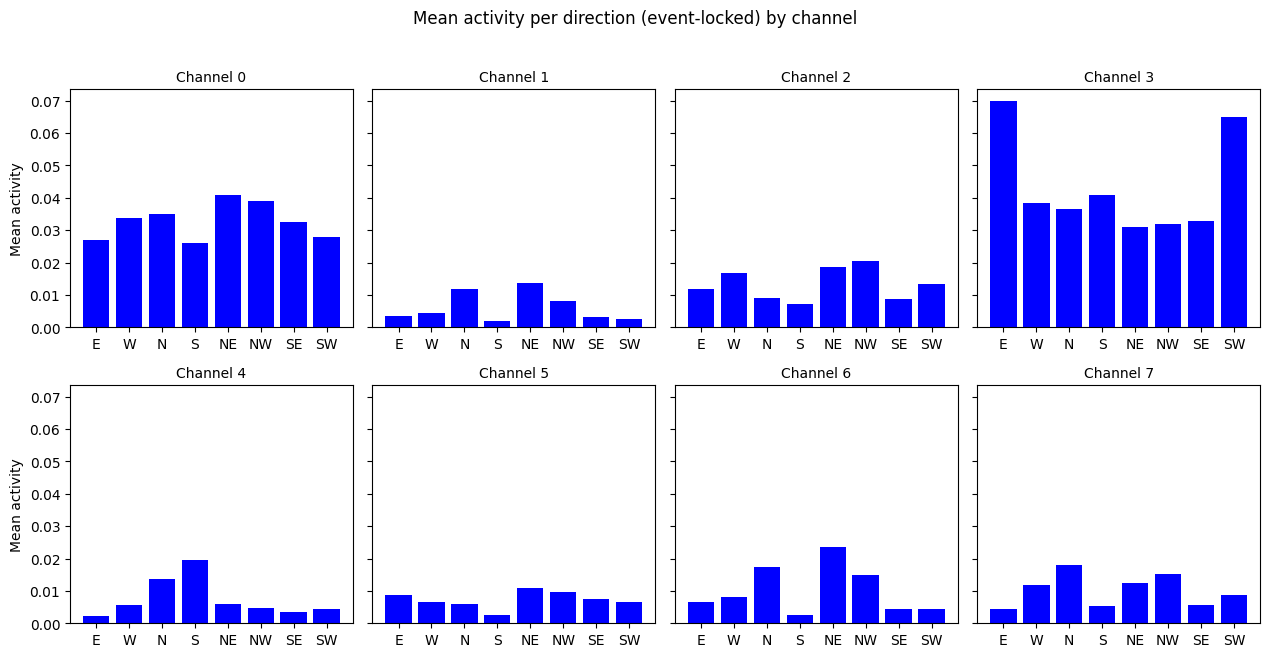

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes:
#   directions: dict[str -> array-like of shape (n_trials, n_channels)]
#   direction_names: dict[str -> pretty label for each key in `directions`]

# pick a consistent order for directions (use direction_names order if provided)
order = [k for k in direction_names.keys() if k in directions]
if not order:
    order = sorted(directions.keys())

labels = [direction_names.get(k, k) for k in order]
num_dirs = len(order)
num_channels = 8  # plot first 8

# precompute mean activity per (channel, direction)
means = np.zeros((num_channels, num_dirs), dtype=float)
for j, key in enumerate(order):
    A = np.asarray(directions[key])  # shape (n_trials, n_channels)
    for ch in range(num_channels):
        means[ch, j] = A[:, ch].mean()

# plot grid
rows, cols = 2, 4
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2), sharey=True)

for ch in range(num_channels):
    ax = axes.flat[ch]
    ax.bar(np.arange(num_dirs), means[ch], color="b")
    ax.set_title(f"Channel {ch}", fontsize=10)
    ax.set_xticks(np.arange(num_dirs))
    ax.set_xticklabels(labels, rotation=0)
    if ch % cols == 0:
        ax.set_ylabel("Mean activity")

fig.suptitle("Mean activity per direction (event-locked) by channel", y=1.02)
fig.tight_layout()
plt.show()

# Modulating w+

In [72]:
n_frames = 40
resolution = (128, 128)
correlation = (0.25,0.75)
max_speed = 1
samples_per_epoch = 20

In [73]:
input2e_name = "rnn.areas.0.convs.0->0.0.weight"
input2i_name = "rnn.areas.0.convs.0->1.0.weight"
e2e_name = "rnn.areas.0.convs.1->0.0.weight"
e2i_name = "rnn.areas.0.convs.1->1.0.weight"
i2i_name = "rnn.areas.0.convs.2->1.0.weight"
i2e_name = "rnn.areas.0.convs.2->0.0.weight"

In [74]:
# Add a blank period to every sample in train_loader and test_loader
def add_blank_to_loader(loader, n_extra_frames, dim):
    # This function returns a new loader with blank frames appended to each sample
    from torch.utils.data import DataLoader, TensorDataset

    all_inputs = []
    all_labels = []
    for batch in loader:
        # batch[0]: (batch_size, n_frames, dim, dim)
        # batch[1]: labels
        inputs, labels = batch
        # Add blank period to each sample in the batch
        # blank_period: (n_extra_frames, dim, dim)
        blank = torch.zeros((inputs.shape[0], n_extra_frames, inputs.shape[2], dim, dim), dtype=inputs.dtype, device=inputs.device)
        inputs_with_blank = torch.cat([inputs, blank], dim=1)
        all_inputs.append(inputs_with_blank)
        all_labels.append(labels)
    all_inputs = torch.cat(all_inputs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    new_dataset = TensorDataset(all_inputs, all_labels)
    new_loader = DataLoader(new_dataset, batch_size=loader.batch_size, shuffle=False)
    return new_loader

In [21]:
param_grid = {
    'coherence': [0.5],
    'n_frames': [5, 10, 20, 30, 40, 45, 50, 55, 60, 65, 70, 75, 80],
    # 'max_speed': [1, 2, 3],             # Uncomment/add parameters freely
    'n_dots': [25, 50, 100, 150, 200],       # Example for easy expansion
    'w_mult': [0.99, 1, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08]
}

In [86]:
# --- Define your parameter grid as a dictionary ---
# 'n_frames': [4, 6, 8, 10, 12, 14, 16, 18, 20, 30, 35, 40, 45, 50, 60],
param_grid = {
    'coherence': [0.5],
    'n_frames': [5, 10, 20, 30, 40, 45, 50, 55, 60, 65, 70, 75, 80],
    'max_speed': [1],             # Uncomment/add parameters freely
    'n_dots': [200],       # Example for easy expansion
    'w_mult': [1, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08]
}

# Make ordered list of param names and value lists
param_names = list(param_grid.keys())
param_value_lists = [param_grid[k] for k in param_names]

# Preallocate output array
shape = [len(vs) for vs in param_value_lists]
all_accuracies = np.full(shape, np.nan, dtype=float)

#two types of working memory plots
add_after_forty = True
add_twenty_to_all = False
if add_after_forty and add_twenty_to_all:
    raise ValueError("Cannot have both add_after_forty and add_twenty_to_all set to True")

samples_per_epoch = 256

# Loop over all parameter combinations, storing results in an array
for idx, values in enumerate(tqdm(list(itertools.product(*param_value_lists)))):
    param_combo = dict(zip(param_names, values))
    index = tuple(
        param_grid[name].index(val) for name, val in zip(param_names, values)
    )

    n_frames = param_combo['n_frames']

    if add_after_forty:
        if n_frames > 40:
            gen_frames = 40
        else:
            gen_frames = n_frames
    else:
        gen_frames = n_frames
    

    # Build loader kwargs from this parameterization
    loader_kwargs = {
        'seed': 10,
        'dataset': "correlated_dots",
        'n_dots': param_combo.get('n_dots', 100),
        'resolution': resolution,
        'n_frames': gen_frames,
        'correlation': param_combo.get('coherence', correlation),
        'max_speed': param_combo.get('max_speed', max_speed),
        'samples_per_epoch': samples_per_epoch,
        'batch_size': 32,
    }

    data_loader, test_loader = initialize_dataloader(**loader_kwargs)

    if add_after_forty:
        if n_frames > 40:
            n_extra_frames = n_frames - 40
            data_loader = add_blank_to_loader(data_loader, n_extra_frames, resolution[0])
    elif add_twenty_to_all:
        n_extra_frames = 20
        data_loader = add_blank_to_loader(data_loader, n_extra_frames, resolution[0])

    modulated_classifier = copy.deepcopy(classifier)
    modulated_classifier.rnn.areas[0].convs["1->0"][0].weight.data *= param_combo.get('w_mult', 1)
    modulated_classifier.rnn.areas[0].convs["1->1"][0].weight.data *= param_combo.get('w_mult', 1)
    modulated_classifier.to(device)
    modulated_classifier.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, labels in data_loader:
            x = x.to(device)
            if cfg["model_type"] == "cnn":
                x = x[:, :, 0, :, :]
                if x.shape[1] < 40:
                    # fill with zeros
                    x = torch.cat([x, torch.zeros(x.shape[0], 40 - x.shape[1], x.shape[2], x.shape[3]).to(device)], dim=1)
                logits = modulated_classifier(x).detach().cpu()
            else:
                logits = modulated_classifier(x).detach().cpu()

            if labels.ndim == 2 and labels.size(1) == 1:
                labels = labels.squeeze(1)
            elif labels.ndim != 1:
                raise ValueError(f"Expected labels shape [N] or [N,1], got {tuple(labels.shape)}")

            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total if total > 0 else float('nan')
    all_accuracies[index] = acc

    torch.cuda.empty_cache()
    gc.collect()

100%|██████████| 117/117 [05:51<00:00,  3.00s/it]


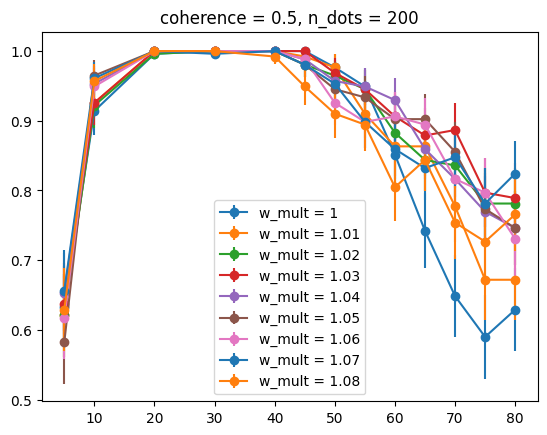

In [87]:
for n_dots_idx in range(len(param_grid["n_dots"])):
    for coherence_idx in range(len(param_grid["coherence"])):
        for w_mult_idx in range(len(param_grid["w_mult"])):
            means = all_accuracies[coherence_idx, :, 0, n_dots_idx, w_mult_idx]
            confidence_interval = 1.96 * np.sqrt(means * (1 - means) / samples_per_epoch)
            plt.errorbar(param_grid["n_frames"], means, yerr=confidence_interval, marker="o", label=f"w_mult = {param_grid['w_mult'][w_mult_idx]}")
        plt.title(f"coherence = {param_grid['coherence'][coherence_idx]}, n_dots = {param_grid['n_dots'][n_dots_idx]}")
        plt.legend()
        plt.show()

# Error RTs

In [51]:
 # Build loader kwargs from this parameterization
loader_kwargs = {
    'seed': 10,
    'dataset': "correlated_dots",
    'n_dots': 100,
    'resolution': (128, 128),
    'n_frames': 40,
    'correlation': 0.15,
    'max_speed': 1,
    'samples_per_epoch': 512,
    'batch_size': 32,
}

data_loader, test_loader = initialize_dataloader(**loader_kwargs)

inputs, labels = [], []
for x, y in data_loader:
    inputs.append(x)
    labels.append(y)

inputs = torch.cat(inputs)
labels = torch.cat(labels)[:, 0]

In [52]:
predictions = np.zeros((len(labels), 40))
timestamp_idxs = np.arange(1, 41)
for timestamp_idx in timestamp_idxs:
    inputs_at_timestamp = inputs[:, :timestamp_idx, :, :, :].to(device)
    logits = classifier(inputs_at_timestamp, num_steps=timestamp_idx).detach().cpu()

    _, predicted = torch.max(logits, 1)
    predictions[:, timestamp_idx - 1] = predicted.numpy()

correct = predictions[:, -1] == labels

In [53]:
decision_points = np.zeros(len(labels))
for sample_idx in range(len(labels)):
    for i in range(39, 0, -1):
        if predictions[sample_idx, i] != predictions[sample_idx, -1]:
            decision_points[sample_idx] = i+1
            break

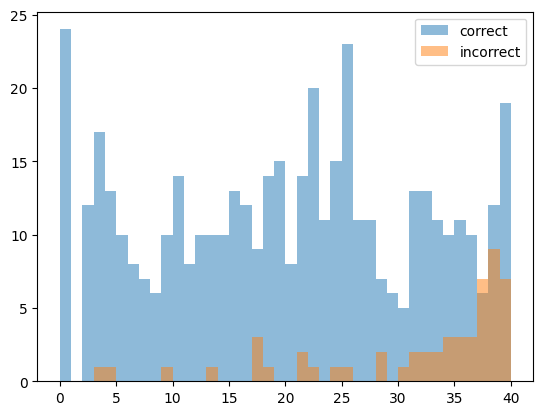

: 

: 

In [ ]:
correct_decision_points = decision_points[correct] 
incorrect_decision_points = decision_points[~correct]

plt.hist(correct_decision_points, bins=np.arange(0, 41, 1), alpha=0.5, label="correct")
plt.hist(incorrect_decision_points, bins=np.arange(0, 41, 1), alpha=0.5, label="incorrect")
plt.legend()
plt.show()
